# EDA - Transactions
Esse notebook aplica uma breve EDA sobre `transactions.json` para entender o tipo de dado presente neste arquivo, quantidade, colunas, tipos de oferta, e outras informações relevantes para o problema e para o processamento de dados.

Pontos observados neste primeiro momento:
1. `event` possui 4 categorias, sendo `transaction` a mais frequente. Podemos observar, em `event`, um tendência decrescente nos valores. Isso indica que nem toda oferta recebida é vista ou completada.
2. Aparentemente, não possuimos dados nulos. Porém, foi necessário verificar `value` (que é um struct), que possui valores nulos nos subcampos.
3. Todo `offer_id` presente em `transactions` existe em `offers.json`. Além disso, `transactions` e `profile` compartilham os mesmos de 17.000 clientes, confirmando integridade entre os três arquivos.
4. Somente 6 pessoas nunca receberam uma oferta. Ou seja, não temos um "grupo controle" neste sentido. Com isso, não vai ser possível fazer uma comparação direta entre "recebeu oferta" x "não recebeu oferta".
5. `time_since_start` é, na verdade, um campo `float`, e não `int`.

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Sessao Spark
spark = SparkSession.builder.appName("ifood-case").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/07/26 18:55:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Leitura do arquivo transactions.json
transactions = spark.read.option("multiline", "true").json(
    "../data/raw/transactions.json"
)

In [4]:
# Exibicao do schema do arquivo transactions.json
transactions.show(n=10, truncate=False)

+--------------------------------+--------------+---------------------+----------------------------------------------------+
|account_id                      |event         |time_since_test_start|value                                               |
+--------------------------------+--------------+---------------------+----------------------------------------------------+
|78afa995795e4d85b5d9ceeca43f5fef|offer received|0.0                  |{NULL, 9b98b8c7a33c4b65b9aebfe6a799e6d9, NULL, NULL}|
|a03223e636434f42ac4c3df47e8bac43|offer received|0.0                  |{NULL, 0b1e1539f2cc45b7b9fa7c272da2e1d7, NULL, NULL}|
|e2127556f4f64592b11af22de27a7932|offer received|0.0                  |{NULL, 2906b810c7d4411798c6938adc9daaa5, NULL, NULL}|
|8ec6ce2a7e7949b1bf142def7d0e0586|offer received|0.0                  |{NULL, fafdcd668e3743c1bb461111dcafc2a4, NULL, NULL}|
|68617ca6246f4fbc85e91a2a49552598|offer received|0.0                  |{NULL, 4d5c57ea9a6940dd891ad53e9dbe8da0, NULL, NULL}|


In [5]:
# Tipo de dado nas colunas do arquivo transactions.json
transactions.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: double (nullable = true)
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



In [6]:
print(
    f"Quantidade de linhas: {transactions.count()}; Quantidade de colunas: {len(transactions.columns)}"
)

Quantidade de linhas: 306534; Quantidade de colunas: 4


In [7]:
# Contagem de registros distintos
print(transactions.count())

306534


In [8]:
# Verificacao de valores nulos
transactions.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in transactions.columns]
).show()

+----------+-----+---------------------+-----+
|account_id|event|time_since_test_start|value|
+----------+-----+---------------------+-----+
|         0|    0|                    0|    0|
+----------+-----+---------------------+-----+



In [9]:
# Verificacao da coluna "event"
transactions.groupBy("event").count().orderBy("count", ascending=False).show(
    truncate=False
)

+---------------+------+
|event          |count |
+---------------+------+
|transaction    |138953|
|offer received |76277 |
|offer viewed   |57725 |
|offer completed|33579 |
+---------------+------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


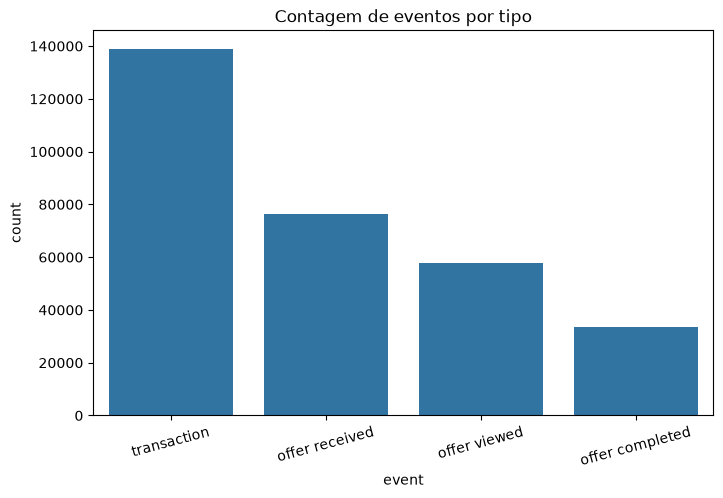

In [10]:
# Distribuicao de "event"
# Nota-se que "transaction" tem maior frequencia.
event_counts = transactions.groupBy("event").count().toPandas()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=event_counts,
    x="event",
    y="count",
    order=event_counts.sort_values("count", ascending=False)["event"],
)
plt.title("Contagem de eventos por tipo")
plt.xticks(rotation=15)
plt.show();

In [11]:
# Schema da coluna "value"
transactions.select("value").printSchema()

root
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



In [12]:
# Inspecao mais detalhada da coluna "event"
# Tem dois "offer id" escritos de forma diferente. Quero tentar entender a qual grupo cada um pertence.
transactions.groupBy("event").agg(
    F.count(F.col("value.amount")).alias("amount_nao_nulo"),
    F.count(F.col("value.`offer id`")).alias("offer_id_com_espaco_nao_nulo"),
    F.count(F.col("value.offer_id")).alias("offer_id_underscore_nao_nulo"),
    F.count(F.col("value.reward")).alias("reward_nao_nulo"),
).show(truncate=False)

+---------------+---------------+----------------------------+----------------------------+---------------+
|event          |amount_nao_nulo|offer_id_com_espaco_nao_nulo|offer_id_underscore_nao_nulo|reward_nao_nulo|
+---------------+---------------+----------------------------+----------------------------+---------------+
|transaction    |138953         |0                           |0                           |0              |
|offer received |0              |76277                       |0                           |0              |
|offer completed|0              |0                           |33579                       |33579          |
|offer viewed   |0              |57725                       |0                           |0              |
+---------------+---------------+----------------------------+----------------------------+---------------+



In [13]:
# Inspecao das "offer_id" + "transaction"
offers = spark.read.option("multiline", "true").json("../data/raw/offers.json")

In [14]:
offer_ids_transactions = (
    transactions.select(
        F.coalesce(F.col("value.`offer id`"), F.col("value.offer_id")).alias("offer_id")
    )
    .filter(F.col("offer_id").isNotNull())
    .distinct()
)

In [15]:
# Verificacao se os ids do arquivo transactions.json estao presentes no arquivo offers.json
offer_ids_transactions.join(
    offers, offer_ids_transactions.offer_id == offers.id, "left_anti"
).show()

+--------+
|offer_id|
+--------+
+--------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


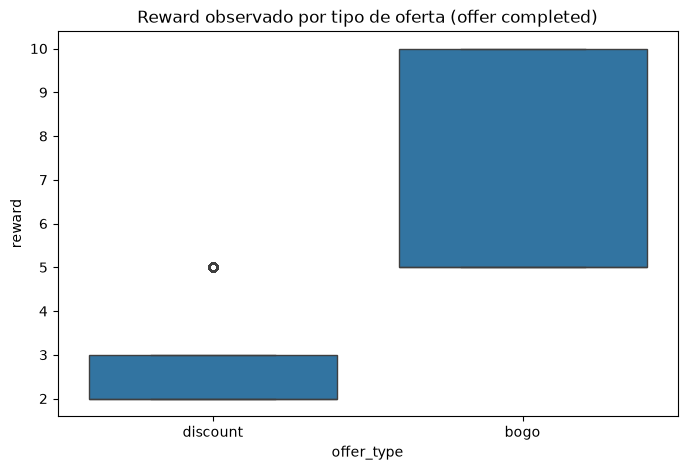

In [16]:
# Distribuição de "reward" para eventos do tipo "offer completed"
rewards = (
    transactions.filter(F.col("event") == "offer completed")
    .select(
        F.col("value.offer_id").alias("offer_id"), F.col("value.reward").alias("reward")
    )
    .join(offers.select("id", "offer_type"), F.col("offer_id") == F.col("id"))
    .toPandas()
)
plt.figure(figsize=(8, 5))
sns.boxplot(data=rewards, x="offer_type", y="reward")
plt.title("Reward observado por tipo de oferta (offer completed)")
plt.show();

In [17]:
# Verificacao do range de dias da coluna "time_since_test_start"
transactions.select(
    F.min("time_since_test_start").alias("min_dia"),
    F.max("time_since_test_start").alias("max_dia"),
).show()

+-------+-------+
|min_dia|max_dia|
+-------+-------+
|    0.0|  29.75|
+-------+-------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


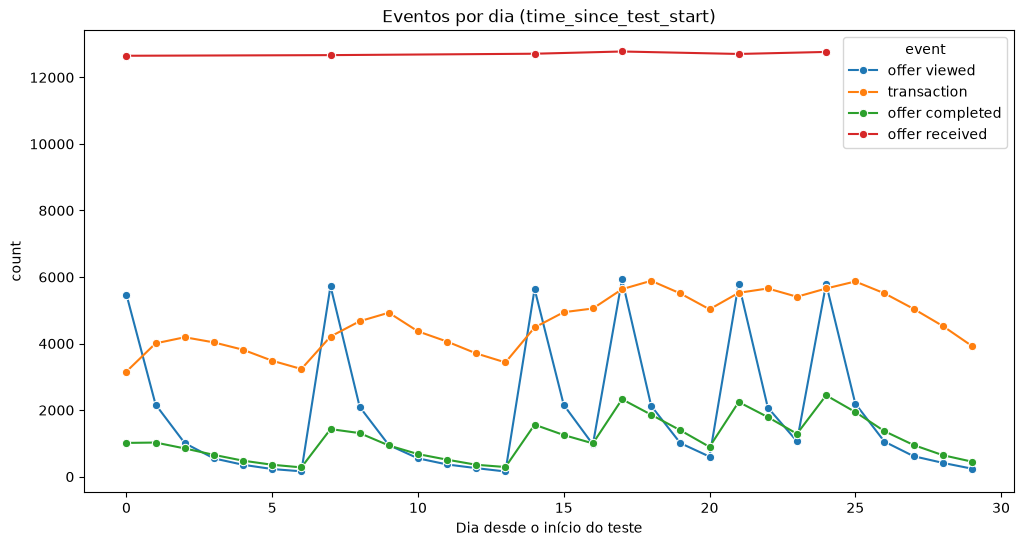

In [18]:
# Linha do tempo dos eventos ao longo do tempo
# Podemos observar "offer received" possui a maior frequencia, enquanto "offer completed" possui a menor frequencia.
# Porem, isso nao acontece em todos os momentos. Exitem periodos onde "offer viewed" possui menor frequencia que
# "offer completed", por exemplo.
timeline = (
    transactions.withColumn("dia", F.floor(F.col("time_since_test_start")))
    .groupBy("dia", "event")
    .count()
    .toPandas()
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=timeline, x="dia", y="count", hue="event", marker="o")
plt.title("Eventos por dia (time_since_test_start)")
plt.xlabel("Dia desde o início do teste")
plt.show();

In [19]:
# Inspecao de profile x transactions
profile = spark.read.option("multiline", "true").json("../data/raw/profile.json")

In [20]:
# Ids distintos em transactions e profile
print(
    "account_id distintos em transactions:",
    transactions.select("account_id").distinct().count(),
)
print("ids distintos em profile:", profile.select("id").distinct().count())

account_id distintos em transactions: 17000
ids distintos em profile: 17000


In [21]:
# Verificacao se os ids do arquivo transactions.json estao presentes no arquivo profile.json
transactions.select("account_id").distinct().join(
    profile, transactions.account_id == profile.id, "left_anti"
).show()

+----------+
|account_id|
+----------+
+----------+



In [22]:
# Verificacao da existencia de conta sem "offer received"
accounts_com_offer_received = (
    transactions.filter(F.col("event") == "offer received")
    .select("account_id")
    .distinct()
)

In [23]:
todos_accounts = transactions.select("account_id").distinct()

In [24]:
print(
    "accounts sem 'offer received':",
    todos_accounts.join(accounts_com_offer_received, "account_id", "left_anti").count(),
)

accounts sem 'offer received': 6


In [25]:
# Ofertas repetidas para mesmas pessoas
transactions.filter(F.col("event") == "offer received").select(
    "account_id",
    F.coalesce(F.col("value.`offer id`"), F.col("value.offer_id")).alias("offer_id"),
).groupBy("account_id", "offer_id").count().filter(F.col("count") > 1).count()

11718

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


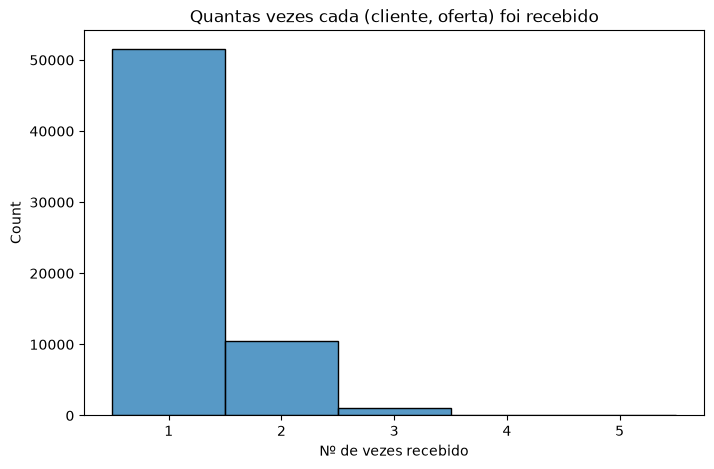

In [26]:
# Distribuicao da quantidade de vezes que cada oferta foi recebida por cliente
repeat_counts = (
    transactions.filter(F.col("event") == "offer received")
    .select(
        "account_id",
        F.coalesce(F.col("value.`offer id`"), F.col("value.offer_id")).alias(
            "offer_id"
        ),
    )
    .groupBy("account_id", "offer_id")
    .count()
    .toPandas()
)
plt.figure(figsize=(8, 5))
sns.histplot(
    repeat_counts["count"],
    bins=range(1, repeat_counts["count"].max() + 2),
    discrete=True,
)
plt.title("Quantas vezes cada (cliente, oferta) foi recebido")
plt.xlabel("Nº de vezes recebido")
plt.show();